# Práctica 4: Multiperceptrón

## Parte 1 - Multiperceptrón con SciKit-Learn

### Ejercicio 1

Se entrenó una red neuronal multiperceptrón para resolver un problema de clasificación y al medir su desempeño sobre el conjunto de datos de entrenamiento se obtuvo la siguiente matriz de confusión: 

| 17 | 0 | 1 | 0 | 1 |
|----|---|---|---|---|
| 0 | 12 | 0 | 0 | 0 |
| 0 | 0 | 12 | 0 | 0 |
| 2 | 0 | 0 | 38 | 0 |
| 0 | 8 | 0 | 0 | 61 |

1. En base a esta información, indique:
   - Cuántos ejemplos se utilizaron en el entrenamiento.
  
Se usaron $152$ ejemplos en el entrenamiento: $152 = 17 + 1 + 1 + 12 + 12 + 2 + 38 + 8 + 61$.

   - Cuántas clases puede reconocer este multiperceptrón.

Puede reconocer 5 clases (número de columnas de la matriz).

   - Cuál es la precisión (**accuracy**) de la red sobre el conjunto de ejemplos completo.

El **accuracy** se calcula como los ejemplos predecidos correctamente / los ejemplos totales: $\frac{140}{152} = 92.10\%$

   - Cuáles son los valores de precisión de la red al responder por cada uno de los valores de clase (**precision**).

La **precisión** a nivel de clase se calcula como los ejemplos predecidos correctamente / los ejemplos predecidos para la clase:
- Clase 1: $\frac{17}{19} = 89.47\%$
- Clase 2: $\frac{12}{20} = 60\%$
- Clase 3: $\frac{12}{13} = 92.31\%$
- Clase 4: $\frac{38}{38} = 100\%$
- Clase 5: $\frac{61}{62} = 98.39\%$

   - Cuáles son los valores de sensibilidad de la red al responder por cada uno de los valores de clase (**recall**).

Lo mismo que antes pero a nivel de fila:
- Clase 1: $\frac{17}{19} = 89.47\%$
- Clase 2: $\frac{12}{12} = 100\%$
- Clase 3: $\frac{12}{12} = 100\%$
- Clase 4: $\frac{38}{40} = 95\%$
- Clase 5: $\frac{61}{69} = 88.40\%$

2. Identifique la clase con el mejor valor de F1-score.

El F1-score se calcula como $2 \cdot \frac{precision\ \cdot\ recall}{precision\ +\ recall}$
- Clase 1: $2 \cdot \frac{0.8947 \cdot 0.8947}{0.8947 + 0.8947} = 0.8947$
- Clase 2: $2 \cdot \frac{0.6 \cdot 1}{0.6 + 1} = 0.75$
- Clase 3: $2 \cdot \frac{0.9231 \cdot 1}{0.9231 + 1} = 0.96$
- Clase 4: $2 \cdot \frac{1 \cdot 0.95}{1 + 0.95} = 0.9743$
- Clase 5: $2 \cdot \frac{0.9839 \cdot 0.8840}{0.9839 + 0.8840} = 0.9312$

La clase con mayor F1-score es la **CLase 4**.

### Ejercicio 2

Se desea utilizar una red multiperceptrón para reconocer muestras de tres variedades diferentes de trigo: Kama, Rosa y Canadiense. Para entrenarla se utilizará una parte de los ejemplos del archivo **SEMILLAS.CSV**.

Fuente de datos: **Seeds Data Set** - [https://archive.ics.uci.edu/ml/datasets/seeds](https://archive.ics.uci.edu/ml/datasets/seeds)

1. Con respecto a la arquitectura, indique:
   - La cantidad de neuronas de la capa de entrada.
  
La cantidad de neuronas de la capa de entrada serían 8 (todas las columnas menos la que queremos predecir + 1 por el bias)

   - La cantidad de neuronas de la capa de salida.

La cantidad de neuronas de la capa de salida serían 3, una por cada tipo de trigo.

   - La cantidad de pesos (arcos) que tiene la red si se utiliza una única capa oculta formada por 4 neuronas.

La cantidad de arcos de la red se calcularía como: $(8 \cdot 4) + (4 \cdot 3) = 44$

2. La arquitectura del multiperceptrón utilizado para predecir los 3 tipos de semillas está formada por 3 capas: la capa de entrada, una única capa oculta de 4 neuronas y la capa de salida. Las funciones de activación para las capas oculta y de salida son “tanh” y “sigmoid” respectivamente. Indique cuáles de los siguientes factores inciden en la dirección de cambio (signo de la modificación) de los pesos de la red:
   - El error cometido en la predicción.
   - El valor de la derivada de la función de activación.
   - Los valores anteriores de los pesos de la red.

Los factores que inciden en la dirección de cambio de los pesos de la red serían El error cometido en la predicción y Los valores anteriores de los pesos de la red.

3. Luego de ingresar una muestra de semilla a la red se obtiene como salida (0.78, 0, 0). Utilizando la arquitectura descripta en b), indique cuántos pesos de la red serán modificados sabiendo que la respuesta esperada es (1, 0, 0).

La cantidad de pesos que se tienen que modificar serían 4 que son los que le llegan a la neurona de la capa de salida que predice Tipo1, y luego todos los que conectan la capa de entrada con la capa oculta, es decir, $(8 \cdot 4) + 4 = 36$.

In [1]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

df_semillas = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\semillas.csv")

df_semillas.head(5)

,Area,Perimetro,Compacidad,LongNucleo,AnchoNucleo,Asimetria,LongSurco,Clase
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Tipo1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Tipo1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Tipo1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Tipo1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Tipo1


### Ejercicio 3

El archivo **Vinos.csv** tiene información referida a 13 características químicas y/o visuales de varias muestras de vinos pertenecientes a 3 clases distintas.

Utilice el 80% de los ejemplos del archivo Vinos.csv para entrenar un multiperceptrón que sea capaz que distinguir entre las 3 clases de vinos. Observe la tasa de acierto obtenida sobre el 20% restante.

Fuente de datos: **Wine Data Set** - [https://archive.ics.uci.edu/ml/datasets/wine]

In [2]:
def visualizar_en_2d(X_scaled, y):
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    if y.ndim > 1:
        y = np.argmax(y, axis=1)

    plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)
    plt.title("Distribución de las clases en 2D usando t-SNE")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

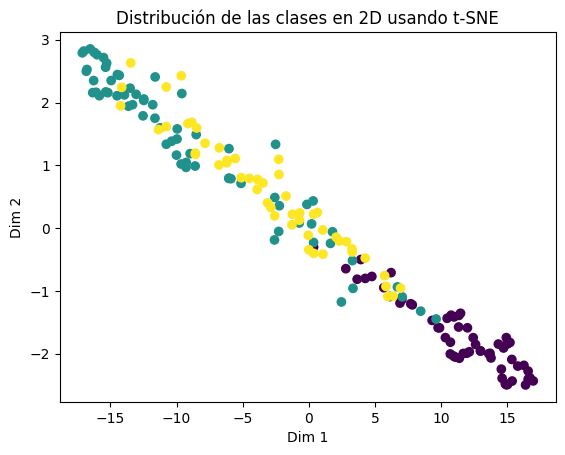

y_pred: [[0 0 1]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]
acc_score: 0.9166666666666666


In [3]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

df_vinos = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\Vinos.csv", delimiter=";")

X = np.array(df_vinos.iloc[:,1:])
y = np.array(df_vinos.iloc[:,0])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(y)

visualizar_en_2d(X, y)

standard_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(2),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    tol=error,
    verbose=False
).fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)

print(f"y_pred: {y_pred}")
print(f"acc_score: {acc_score}")

### Ejercicio 4

El archivo **Balance.csv** tiene información sobre un experimento psicológico realizado para evaluar el aprendizaje en los niños. Cada fila de la tabla tiene las características de una balanza, referidas a la longitud de los brazos izquierdo y derecho de la balanza y al peso que hay en cada brazo, y un atributo que indica si la balanza se inclina al lado izquierdo (**L**), derecho (**R**), o está balanceada (**B**). 

Utilice una parte de los ejemplos para entrenar un multiperceptrón que sea capaz que predecir si la balanza está inclinada a derecha, a izquierda o si está balanceada. Analice la precisión de la red sobre los ejemplos de entrenamiento y sobre los de testeo.

Fuente: **Balance Scale Data Set** - [https://archive.ics.uci.edu/ml/datasets/Balance+Scale](https://archive.ics.uci.edu/ml/datasets/Balance+Scale) 

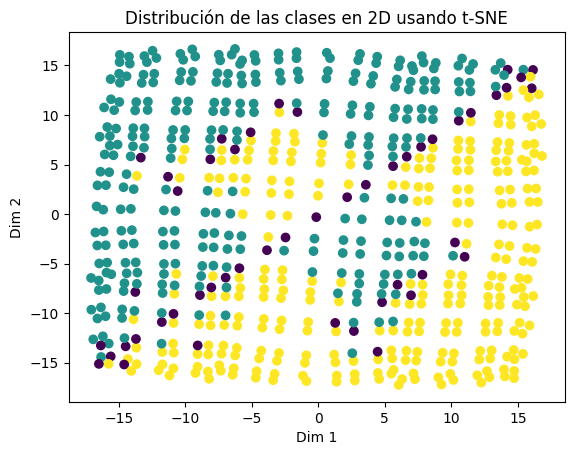

y_pred_train: [[0 0 1]
 [0 1 0]
 [0 0 1]
 ...
 [0 0 1]
 [0 1 0]
 [0 0 1]]
acc_score_train: 0.988
y_pred_test: [[0 0 1]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 0 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 0 1]

In [4]:
df_balance = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\Balance.csv")

X = np.array(df_balance.iloc[:,1:])
y = np.array(df_balance.iloc[:,0])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(y)

visualizar_en_2d(X, y)

standard_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(7, 6),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    tol=error,
    verbose=False
).fit(
    X_train,
    y_train
)

y_pred_train = model.predict(X_train)
acc_score_train = accuracy_score(y_train, y_pred_train)
y_pred_test = model.predict(X_test)
acc_score_test = accuracy_score(y_test, y_pred_test)

print(f"y_pred_train: {y_pred_train}")
print(f"acc_score_train: {acc_score_train}")
print(f"y_pred_test: {y_pred_test}")
print(f"acc_score_test: {acc_score_test}")

### Ejercicio 5

El archivo **ZOO.csv** contiene información de 101 animales caracterizados por los siguientes atributos:

1. Nombre del animal 
2. Tiene Pelo  
3. Plumas   
4. Huevos   
5. Leche   
6. Vuela  
7. Acuático   
8. Depredador  
9. Dentado   
10. Vertebrado      
11. Branquias   
12. Venenoso   
13. Aletas   
14. Patas 
15. Cola   
16. Domestico   
17. Tamaño gato  
18. Clase

Salvo los atributos 1 y 18 que contienen texto y el 14 que contiene el número de patas del animal, el resto toma el valor 1 si el animal posee la característica y 0 si no. Hay 7 valores de clase posible (atributo 18): mamífero, ave, pez, invertebrado, insecto, reptil y anfibio.

Entrene un multiperceptrón que sea capaz de clasificar un animal en una de las 7 clases. Utilice el 70% de los ejemplos para entrenar y el 30% para realizar el testeo. Realice al menos 10 ejecuciones independientes de la configuración seleccionada para respaldar sus afirmaciones referidas a la performance del modelo.

Fuente de Datos: **Zoo Data Set** - [https://archive.ics.uci.edu/ml/datasets/zoo](https://archive.ics.uci.edu/ml/datasets/zoo)

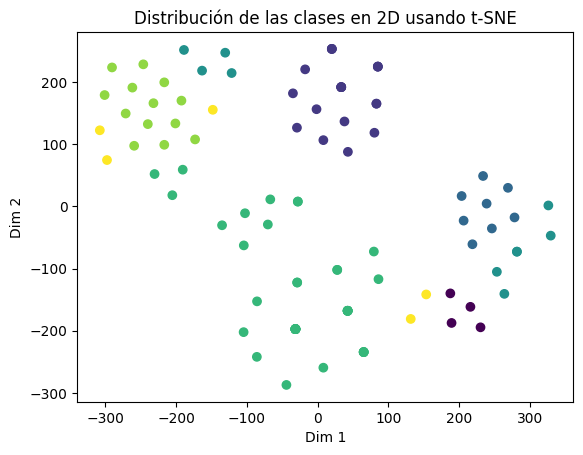

acc_score model 1: 0.9032258064516129
acc_score model 2: 0.9032258064516129
acc_score model 3: 0.9032258064516129
acc_score model 4: 0.9032258064516129
acc_score model 5: 0.9032258064516129
acc_score model 6: 0.9032258064516129
acc_score model 7: 0.9032258064516129
acc_score model 8: 0.9032258064516129
acc_score model 9: 0.9032258064516129
acc_score model 10: 0.9032258064516129


In [5]:
df_zoo = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\zoo.csv", encoding="latin1")

X = np.array(df_zoo.iloc[:,1:-1])
y = np.array(df_zoo.iloc[:,-1])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(y)

visualizar_en_2d(X, y)

standard_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.01
error = 1.0e-4
iteraciones = 5000

for i in range(10):
    model = MLPClassifier(
        max_iter=iteraciones,
        hidden_layer_sizes=(29, 14),
        alpha=alpha,
        solver="adam",
        activation="tanh",
        tol=error,
        verbose=False
    ).fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)
    acc_score = accuracy_score(y_test, y_pred)

    # print(f"y_pred model {i + 1}: {y_pred}")
    print(f"acc_score model {i + 1}: {acc_score}")

### Ejercicio 6

Los archivos **Segment_Train.csv** y **Segment_Test.csv** contienen información referida a regiones de 3x3 pixeles pertenecientes a 7 imágenes distintas. Cada una corresponde a uno de los siguientes tipos de superficie: ladrillo, cielo, follaje, cemento, ventana, camino y pasto.

Cada región de 3x3 ha sido caracterizada por 19 atributos numéricos: 
1. **region-centroid-col**: la columna del pixel central de la región. 
2. **region-centroid-row**: la fila del pixel central de la región. 
3. **region-pixel-count**: el número de pixeles de la región = 9. 
4. **short-line-density-5**: el resultado de un algoritmo de extracción de líneas que cuenta la cantidad de líneas de bajo contraste que atraviesan la región. 
5. **short-line-density-2**: ídem anterior para líneas de alto contraste. 
6. **vedge-mean**: medida del contraste entre pixeles adyacentes. Este atributo contiene el valor promedio y el siguiente la desviación. Estas medidas sirven para detectar la presencia de un eje vertical. 
7. **vegde-sd**: (ver 6) 
8. **hedge-mean**: ídem 6 para eje horizontal. Contiene el valor medio y el siguiente la desviación.  
9. **hedge-sd**: (ver 8). 
10. **intensity-mean**: El promedio calculado sobre la región de la forma (R + G + B)/3 
11. **rawred-mean**: el promedio sobre la región de los valores R.  
12. **rawblue-mean**: el promedio sobre la región de los valores B. 
13. **rawgreen-mean**: el promedio sobre la región de los valores G. 
14. **exred-mean**: Medida de exceso de color rojo: (2R - (G + B)) 
15. **exblue-mean**: Medida de exceso de color azul: (2B - (G + R)) 
16. **exgreen-mean**: Medida de exceso de color verde: (2G - (R + B)) 
17. **value-mean**: Transformación no lineal 3D de RGB. 
18. **saturatoin-mean**: (ver 17) 
19. **hue-mean**: (ver 17)

El atributo 20 corresponde al número de imagen de la cual fue extraída la región de 3x3. Sus valores son: 1 (ladrillo), 2 (cemento), 3(follaje), 4 (pasto), 5 (camino), 6 (cielo), 7 (ventana).

Entrene una red neuronal multiperceptrón para que dada una región de 3x3, representada a través de los 19 atributos indicados anteriormente, sea capaz de identificar a cuál de las 7 imágenes corresponde. Utilice los ejemplos del archivo **Segment_Train.csv** para entrenar y los del archivo **Segment_Test.csv** 
para realizar el testeo. Realice al menos 10 ejecuciones independientes de la configuración seleccionada para respaldar sus afirmaciones referidas a la performance del modelo.

Fuente: **Image Segmentation Data Set**: [https://archive.ics.uci.edu/ml/datasets/Image+Segmentation](https://archive.ics.uci.edu/ml/datasets/Image+Segmentation)

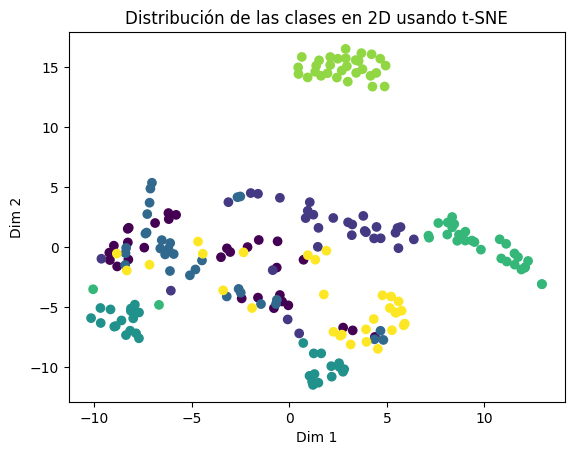

acc_score model 1: 0.8647619047619047
acc_score model 2: 0.8647619047619047
acc_score model 3: 0.8647619047619047
acc_score model 4: 0.8647619047619047
acc_score model 5: 0.8647619047619047
acc_score model 6: 0.8647619047619047
acc_score model 7: 0.8647619047619047
acc_score model 8: 0.8647619047619047
acc_score model 9: 0.8647619047619047
acc_score model 10: 0.8647619047619047


In [6]:
# Definimos las columnas correctas (con CLASS al principio)
cols = [
    "CLASS",
    "REGION-CENTROID-COL", "REGION-CENTROID-ROW", "REGION-PIXEL-COUNT",
    "SHORT-LINE-DENSITY-5", "SHORT-LINE-DENSITY-2",
    "VEDGE-MEAN", "VEDGE-SD", "HEDGE-MEAN", "HEDGE-SD",
    "INTENSITY-MEAN", "RAWRED-MEAN", "RAWBLUE-MEAN", "RAWGREEN-MEAN",
    "EXRED-MEAN", "EXBLUE-MEAN", "EXGREEN-MEAN",
    "VALUE-MEAN", "SATURATION-MEAN", "HUE-MEAN"
]

# Leemos el CSV especificando que no hay encabezado y usando el motor Python
df_seg_train = pd.read_csv(
    r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\segment_train.csv",
    header=None,
    names=cols,
    engine='python'
)

df_seg_test = pd.read_csv(
    r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\segment_test.csv",
    header=None,
    names=cols,
    engine='python'
)

# Eliminar la primera fila (que contiene los encabezados viejos)
df_seg_train = df_seg_train.drop(index=0).reset_index(drop=True)
df_seg_test = df_seg_test.drop(index=0).reset_index(drop=True)

X_seg_train = np.array(df_seg_train.iloc[:,1:])
y_seg_train = np.array(df_seg_train.iloc[:,0])
X_seg_test = np.array(df_seg_test.iloc[:,1:])
y_seg_test = np.array(df_seg_test.iloc[:,0])

label_binarizer = LabelBinarizer()
y_seg_train = label_binarizer.fit_transform(y_seg_train)
y_seg_test = label_binarizer.transform(y_seg_test)

visualizar_en_2d(X_seg_train, y_seg_train)

standard_scaler = StandardScaler()
X_seg_train = standard_scaler.fit_transform(X_seg_train)
X_seg_test = standard_scaler.transform(X_seg_test)

alpha = 0.01
error = 1.0e-4
iteraciones = 5000

for i in range(10):
    model = MLPClassifier(
        max_iter=iteraciones,
        hidden_layer_sizes=(30, 15),
        alpha=alpha,
        solver="adam",
        activation="tanh",
        tol=error,
        verbose=False,
        random_state=42
    ).fit(
        X_seg_train,
        y_seg_train
    )

    y_pred = model.predict(X_seg_test)
    acc_score = accuracy_score(y_seg_test, y_pred)

    # print(f"y_pred model {i + 1}: {y_pred}")
    print(f"acc_score model {i + 1}: {acc_score}")

---


## Parte 2 - Multiperceptrón con Tensorflow/Keras

### Ejercicio 7

Re-implemente el modelo del ejercicio 4 (Balance.csv) utilizando un Multiperceptrón Tensorflow/Keras.

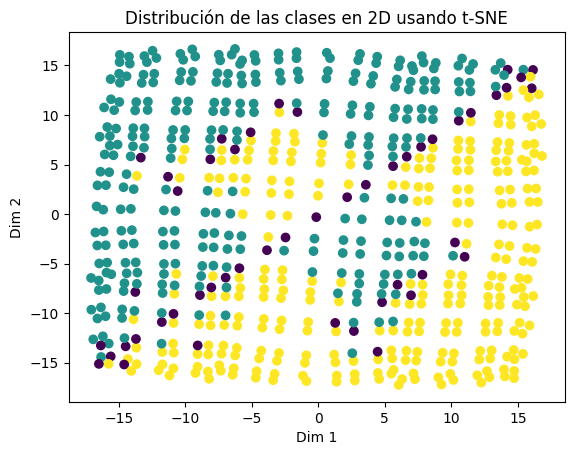

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 7)                   │              35 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 104 (416.00 B)

 Trainable params: 104 (416.00 B)

 Non-trainable params: 0 (0.00 B)

Accuracy en entrenamiento: 0.9880
Accuracy en test: 0.9520


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Flatten, Input, LeakyReLU
from tensorflow.keras.optimizers import SGD

df_balance = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\Balance.csv")

X = np.array(df_balance.iloc[:,1:])
y = np.array(df_balance.iloc[:,0])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(y)

visualizar_en_2d(X, y)

standard_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(7, activation="leaky_relu"))
model.add(Dense(6, activation="tanh"))
model.add(Dense(3, activation="softmax"))

model.summary()

model.compile(
    optimizer=SGD(learning_rate=0.05),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=1000,
    batch_size=64,
    verbose=0,
    validation_split=0.1
)

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Accuracy en entrenamiento: {train_acc:.4f}")
print(f"Accuracy en test: {test_acc:.4f}")

### Ejercicio 8

Utilizando el archivo **Iris.csv** que contiene información referida a la longitud y al ancho de sépalos y pétalos de tres especies de flores: iris setosa, iris versicolor e iris virginica.

1. Entrenar una multiperceptrón que aprenda a clasificar las 3 clases de flores.
2. Utilice Python para calcular la matriz de confusión y calcule de forma manual las métricas de **precision, recall, accuracy y f1-score**. Luego utilice la función **classification_report** de SciKit-Learn para comparar los resultados.

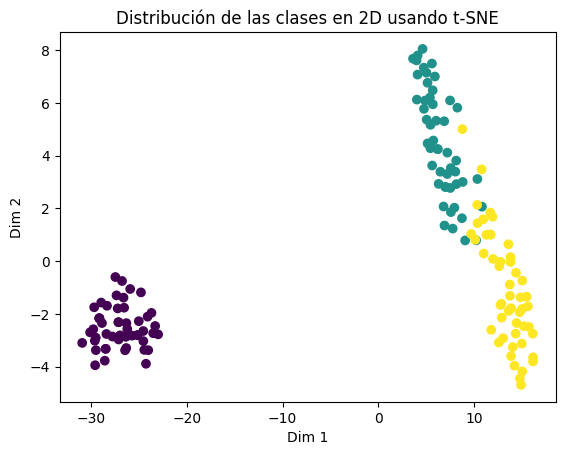

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 10)                  │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │              55 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Matriz de confusión:
 [[ 9  1  0]
 [ 0 10  0]
 [ 0  1  9]]
Accuracy: 0.933
Precision: [1.0, 0.833, 1.0]
Recall: [0.9, 1.0, 0.9]
F1-score: [0.947, 0.909, 0.947]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.83      1.00      0.91        10
           2       1.00      0.90      0.95        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [8]:
from sklearn.metrics import confusion_matrix, classification_report

df_iris = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\Iris.csv")

df_iris.head(10)

X = np.array(df_iris.iloc[:,1:-1])
y = np.array(df_iris.iloc[:,-1])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(y)

visualizar_en_2d(X, y)

standard_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(10, activation="leaky_relu"))
model.add(Dense(5, activation="tanh"))
model.add(Dense(3, activation="softmax"))

model.summary()

model.compile(
    optimizer=SGD(learning_rate=0.05),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=1000,
    batch_size=64,
    verbose=0,
    validation_split=0.1
)

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)  # clases predichas como enteros
y_true = np.argmax(y_test, axis=1)       # clases reales como enteros

cm = confusion_matrix(y_true, y_pred)
print("Matriz de confusión:\n", cm)

# Metricas a manopla
precision = []
recall = []

for i in range(cm.shape[0]):
    TP = cm[i,i]
    FP = cm[:,i].sum() - TP
    FN = cm[i,:].sum() - TP
    precision.append(TP / (TP + FP))
    recall.append(TP / (TP + FN))

accuracy = np.trace(cm) / np.sum(cm)
f1_score = [2*p*r/(p+r) for p,r in zip(precision, recall)]

# Formateando las métricas para que se vean más limpias
precision_fmt = [round(float(p), 3) for p in precision]
recall_fmt = [round(float(r), 3) for r in recall]
f1_fmt = [round(float(f), 3) for f in f1_score]

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision_fmt}")
print(f"Recall: {recall_fmt}")
print(f"F1-score: {f1_fmt}")

print(classification_report(y_true, y_pred))

### Ejercicio 9

Utilizando los ejemplos del archivo **AUTOS.csv** genere un modelo utilizando un multiperceptrón para predecir el precio del auto (atributo **price**) y la cantidad de millas por galón en ruta (**MPG-highway**) en función del resto de los atributos. Recuerde completar los valores faltantes, utilizar normalización y dividir el dataset en entrenamiento y validación (80/20). 

Realice 20 ejecuciones independientes de cada configuración seleccionada calculando las épocas promedio y al error cuadrático medio (ECM). Analice los resultados y respalde las afirmaciones referidas a los resultados obtenidos. Utilice un máximo de 1000 épocas con lotes de 50 e implemente una parada temprana con paciencia de 15.

Complete la siguiente tabla y realice un análisis de los valores obtenidos. Donde:
- **Épocas Promedio** es el número de épocas promedio en el que se detuvo el entrenamiento.
- **ECM Promedio** es el promedio del error de predicción en cada entrenamiento.

| Optimizador | Function activation | Épocas promedio | ECM Promedio |
|-------------|---------------------|-----------------|--------------|
| SGD         | tanh                | 286.6           | 0.1805       |
|             | sigmoid             | 723.0           | 0.2268       |
|             | ReLU                | 223.2           | 0.1978       |
|             | LeakyReLU           | 175.4           | 0.1451       |
| RMSProp     | tanh                | 54.3            | 0.2884       |
|             | sigmoid             | 81.5            | 0.2292       |
|             | ReLU                | 58.9            | 0.2498       |
|             | LeakyReLU           | 44.5            | 0.2373       |
| Adam        | tanh                | 64.3            | 0.1987       |
|             | sigmoid             | 80.2            | 0.1780       |
|             | ReLU                | 59.0            | 0.1672       |
|             | LeakyReLU           | 45.9            | 0.1401       |

In [10]:
from tensorflow.keras.optimizers import RMSprop, Adam

df_autos = pd.read_csv(
    r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\autos.csv",
    na_values=['?', '??', 'NA', '', 'null']
)

df_autos = df_autos.select_dtypes(include=np.number)

valores_faltantes = {
    'normalized-losses': df_autos['normalized-losses'].mean(),
    'bore': df_autos['bore'].mean(),
    'stroke': df_autos['stroke'].mean(),
    'horsepower': df_autos['horsepower'].mean(),
    'peak-rpm': df_autos['peak-rpm'].mean(),
    'price': df_autos['price'].mean()
}

df_autos = df_autos.fillna(value=valores_faltantes)

y = np.array(df_autos[["highway-mpg", "price"]])
X = df_autos.drop(["highway-mpg", "price"], axis=1).values

data_scaler, target_scaler = StandardScaler(), StandardScaler()
X = data_scaler.fit_transform(X)
y = target_scaler.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="tanh"))
    model.add(Dense(3, activation="tanh"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=SGD(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - SGD con tanh")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="sigmoid"))
    model.add(Dense(3, activation="sigmoid"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=SGD(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - SGD con sigmoid")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="relu"))
    model.add(Dense(3, activation="relu"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=SGD(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - SGD con relu")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="leaky_relu"))
    model.add(Dense(3, activation="leaky_relu"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=SGD(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - SGD con leaky_relu")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                     │ (None, 6)                   │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 3)                   │              21 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 2)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_303 (Dense)                    │ (None, 6)                   │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_304 (Dense)                    │ (None, 3)                   │              21 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_305 (Dense)                    │ (None, 2)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
Epocas utilizadas: 122
ECM final: 0.1443

RESULTADOS PARA TABLA - SGD con leaky_relu
Épocas promedio: 175.4
ECM promedio: 0.1451


In [11]:
epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="tanh"))
    model.add(Dense(3, activation="tanh"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=RMSprop(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - RMSprop con tanh")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="sigmoid"))
    model.add(Dense(3, activation="sigmoid"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=RMSprop(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - RMSprop con sigmoid")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="relu"))
    model.add(Dense(3, activation="relu"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=RMSprop(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - RMSprop con relu")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="leaky_relu"))
    model.add(Dense(3, activation="leaky_relu"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=RMSprop(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - RMSprop con leaky_relu")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_306 (Dense)                    │ (None, 6)                   │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_307 (Dense)                    │ (None, 3)                   │              21 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_308 (Dense)                    │ (None, 2)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_543 (Dense)                    │ (None, 6)                   │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_544 (Dense)                    │ (None, 3)                   │              21 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_545 (Dense)                    │ (None, 2)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
Epocas utilizadas: 51
ECM final: 0.2007

RESULTADOS PARA TABLA - RMSprop con leaky_relu
Épocas promedio: 44.5
ECM promedio: 0.2373


In [12]:
epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="tanh"))
    model.add(Dense(3, activation="tanh"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - Adam con tanh")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="sigmoid"))
    model.add(Dense(3, activation="sigmoid"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - Adam con sigmoid")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="relu"))
    model.add(Dense(3, activation="relu"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - Adam con relu")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

epocas_lista = []
ecm_lista = []

for i in range(20):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(6, activation="leaky_relu"))
    model.add(Dense(3, activation="leaky_relu"))
    model.add(Dense(2))

    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.05),
        loss='mse',
        metrics = ['mae', 'mse']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=50,
        verbose=0,
        validation_data = (X_test, y_test),
        callbacks=[early_stop]
    )

    epocas_utilizadas = len(history.epoch)
    ecm_final = history.history['val_loss'][-1]
    epocas_lista.append(epocas_utilizadas)
    ecm_lista.append(ecm_final)
    
    print('\n'+'-'*80)
    print('Epocas utilizadas: %d' % len(history.epoch))
    print(f'ECM final: {ecm_final:.4f}')

epocas_promedio = np.mean(epocas_lista)
ecm_promedio = np.mean(ecm_lista)

print("\n" + "="*60)
print("RESULTADOS PARA TABLA - Adam con leaky_relu")
print("="*60)
print(f"Épocas promedio: {epocas_promedio:.1f}")
print(f"ECM promedio: {ecm_promedio:.4f}")

Model: "sequential_182"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_546 (Dense)                    │ (None, 6)                   │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_547 (Dense)                    │ (None, 3)                   │              21 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_548 (Dense)                    │ (None, 2)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_783 (Dense)                    │ (None, 6)                   │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_784 (Dense)                    │ (None, 3)                   │              21 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_785 (Dense)                    │ (None, 2)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
Epocas utilizadas: 24
ECM final: 0.1400

RESULTADOS PARA TABLA - Adam con leaky_relu
Épocas promedio: 45.9
ECM promedio: 0.1401


### Ejercicio 10

El conjunto de datos **“Fingers”** consiste en una serie de imágenes de 64x64 píxeles con fondo negro donde en su centro se encuentra un mano que muestra una cantidad de dedos que va desde 0 a 5. La versión original de este conjunto de imágenes se encuentra en [https://www.kaggle.com/koryakinp/fingers](https://www.kaggle.com/koryakinp/fingers)

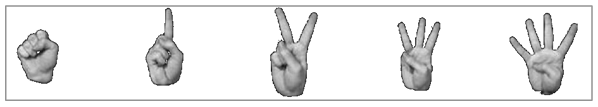

Muchas veces se utilizan técnicas de procesamiento de imágenes para obtener características representativas (features extraction) de los objetos dentro de una imagen con el objetivo de simplificar el problema, reducir la dimensionalidad y/o reducir el costo de procesamiento. Bibliotecas como **OpenCV** o **SciKit-Learn** proveen funciones que permiten procesar imágenes y obtener valores estadísticos que caracterizan los objetos.

1. Utilice la función **regionprops** de **SciKitLearn** con algunas imágenes de ejemplo del dataset para experimentar con las distintas características que extrae de la imagen de la mano.
2. Implemente un script que convierta las imágenes en las carpetas **“test”** y **“train”** del dataset **“Fingers”** en dos archivos (uno por carpeta) separados por comas (csv). De todas las características que provee **regionprops**, tienen potencial aquellas que son independientes o se pueden independizar de las unidades (píxeles). Algunas de estas características pueden ser:
   - **filled_area**: cantidad de píxeles que contiene región (podría interpretarse como píxeles cuadrados).
   - **major_axis_length**: longitud (en píxeles) del eje mayor de la elipse que mejor se ajusta a la región.
   - **minor_axis_length**: longitud (en píxeles) del eje menor de la elipse que mejor se ajusta a la región.
   - **perimeter**: cantidad de píxeles que forman el contorne de la región.
   - **eccentricity**: excentricidad de la elipse de mejor ajuste, cerca de 0 es un círculo, mientras que cerca de 1 es una elipse más “larga”.
   - **solidity**: razón entre la cantidad de píxeles de la región original y de la región convexa. Para generar una región convexa se completan los pixeles de forma de eliminar regiones cóncavas de una figura. La región convexa de una estrella de 5 puntas se convertirá en un pentágono al completarla.
   - **extent**: razón entre pixeles de la región original y el rectángulo que la contiene (bounding box). 
3. Entrene un modelo de multiperceptrón a partir del archivo de entrenamiento generado en el punto anterior.
4. Reflexione acerca de las propiedades geométricas generadas a partir de un objeto/región de una imagen. ¿Cómo cree que afectaría la rotación, translación y escalado de un objeto/región dentro de la imagen?

Está basicamente hecho en los notebooks que nos proporciona la cátedra